<a href="https://colab.research.google.com/github/joaocanaslopes/notebooks_aulas/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and Visualization of Complex Agro-Environmental Data
---
## Regression

### 1. Run simple linear regression

Simple linear regression is the simplest form of regression analysis. It is also commonly used in Exploratory Data Analysis when we are interested in exploring if a given continuous response variable is affected by other independent (or predictor) variables. When we aim at modelling a response continuous variable with multiple linear regression using a big set of potential candidate variables, simple regression analysis is often used as a first filter to select a subset of candidate variables. Again, significant effect of a predictor on the response variable does not imply causation; but causation implies a significant an effect of a predictor on the response. Along with correlation analysis, regression is also important as a basis to establish hypothesis to be tested with more elaborated confirmatory statistics.

Linear regression models may be run with several python modules such as SciPy, statsmodel and scikit-learn.

##### Example with the [penguin](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data) dataset

In [1]:
# import the packages we are going to be using
import numpy as np # for getting our distribution
import pandas as pd # to handle data frames
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for plotting
from scipy import stats # to compute statistics

# import data ('penguin' dataset)
data = pd.read_csv('penguins_lter.csv', sep=";")
data.drop(data.iloc[:,14:18], axis=1, inplace=True)
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            333 non-null    object 
 1   Sample Number        333 non-null    int64  
 2   Species              333 non-null    object 
 3   Region               333 non-null    object 
 4   Island               333 non-null    object 
 5   Stage                333 non-null    object 
 6   Individual ID        333 non-null    object 
 7   Clutch Completion    333 non-null    object 
 8   Date Egg             333 non-null    object 
 9   Culmen Length (mm)   333 non-null    float64
 10  Culmen Depth (mm)    333 non-null    float64
 11  Flipper Length (mm)  333 non-null    float64
 12  Body Mass (g)        333 non-null    float64
 13  Sex                  333 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 39.0+ KB


Let's regress the variable 'body mass' against 'culmen depth'

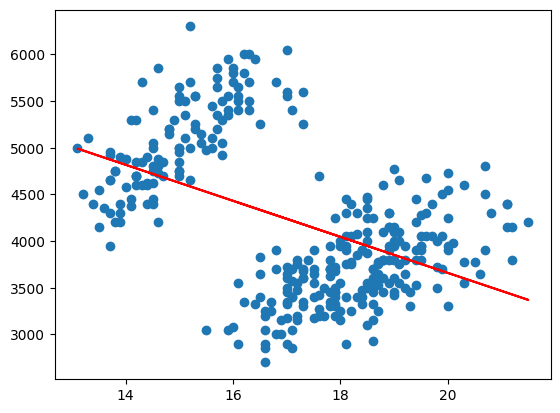

In [2]:
# Use the `penguin` dataset to relate body mass as function of culmen depth (i.e. to infer body mass from culmen depth)

x=data["Culmen Depth (mm)"]
y=data["Body Mass (g)"]

# Execute a function that returns some important key values of Linear Regression:
slope, intercept, r, p, std_err = stats.linregress(x, y)

# plot data with fitted line
def myfunc(x):
  return intercept + slope * x # function that returns fitted values

mymodel = list(map(myfunc, x)) # apply function to each x value

plt.scatter(x, y)
plt.plot(x, mymodel, color="red")
plt.show()

The overal relationship tends to be negative. Now we will test the null hypothesis that the slope of relationship is zero

In [3]:
# Run the regression test
print('slope estimate=%.2f, r-square=%.3f, p=%.6f' % (slope, r**2, p))
alpha=0.05
if p <= alpha:
 print('reject H0 that the slope of the relationship is = 0')
else:
 print('fail to reject H0 that the slope of the relationship is = 0')

slope estimate=-193.01, r-square=0.223, p=0.000000
reject H0 that the slope of the relationship is = 0


The **statsmodel** module provides a more complete output using much less code:

In [4]:
import statsmodels.api as sm

x2 = x
x2 = sm.add_constant(x2) # adding a constant (Intercept)

model = sm.OLS(y, x2).fit()
predictions = model.predict(x2)

print_model = model.summary()
print(print_model)

# Some notes on model outputs:

# Omnibus tests are a kind of statistical test. They test whether the explained variance in a
# set of data is significantly greater than the unexplained variance, overall. One example is the F-test in the analysis of variance.

# The Durbin Watson statistic is a test for autocorrelation in a regression model's output.
# The statistic ranges from zero to four, with a value of 2.0 indicating zero autocorrelation.

# Jarque–Bera test is a goodness-of-fit test of whether sample data have the skewness and kurtosis matching a normal distribution.

# The adjusted r-square adjusts the value of R2 to avoid overestimating the impact of adding independent variables to the model.

                            OLS Regression Results                            
Dep. Variable:          Body Mass (g)   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     94.89
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           7.02e-20
Time:                        11:32:52   Log-Likelihood:                -2658.2
No. Observations:                 333   AIC:                             5320.
Df Residuals:                     331   BIC:                             5328.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              7519.9808    342.32

### Explanation of Model Output Terms:

*   **R-squared:** This represents the proportion of the variance in the dependent variable (Body Mass in this case) that can be explained by the independent variable(s) (Culmen Depth). A higher R-squared value indicates a better fit of the model to the data. It ranges from 0 to 1.

*   **Adj. R-squared (Adjusted R-squared):** This is a modified version of R-squared that has been adjusted for the number of predictors in the model. It increases only if the new predictor improves the model more than would be expected by chance, making it useful for comparing models with different numbers of predictors. It helps to avoid overfitting.

*   **F-statistic:** This is a statistical test used to assess the overall significance of the regression model. It tests the null hypothesis that all the regression coefficients are equal to zero (meaning none of the independent variables have a significant effect on the dependent variable). A larger F-statistic and a smaller p-value (Prob (F-statistic)) suggest that the model is statistically significant.

*   **Prob (F-statistic):** This is the p-value associated with the F-statistic. It indicates the probability of observing such an F-statistic if the null hypothesis (all regression coefficients are zero) were true. A small p-value (typically < 0.05) suggests that the overall model is statistically significant.

*   **Log-Likelihood:** This is a measure of how well the model fits the data. In general, a higher log-likelihood value indicates a better-fitting model. It's often used when comparing different models, especially with information criteria.

*   **AIC (Akaike Information Criterion):** This is a measure of the relative quality of statistical models for a given set of data. It provides a means for model selection. AIC balances the goodness of fit of the model with the complexity of the model (number of parameters). Lower AIC values generally indicate a better model.

*   **BIC (Bayesian Information Criterion):** Similar to AIC, BIC is another criterion for model selection. It also considers the number of parameters and the goodness of fit, but it penalizes model complexity more heavily than AIC, especially for larger datasets. Lower BIC values are preferred.

There are other modules that have implemented regression analysis, such as the **sklearn** module:

In the previous regression, the Durbin-Watson (DW) statistic is close to 2, which suggests that there is no significant autocorrelation in the residuals.
However, the Jarque-Bera (JB) test indicates that errors are not normally distributed (p-value < 0.05). This is a problem because the OLS regression model assumes that errors are normally distributed. This may be caused by the data grouping as shown by the scatter plot above, which is probably related with the different species present in the dataset. Let's check that.

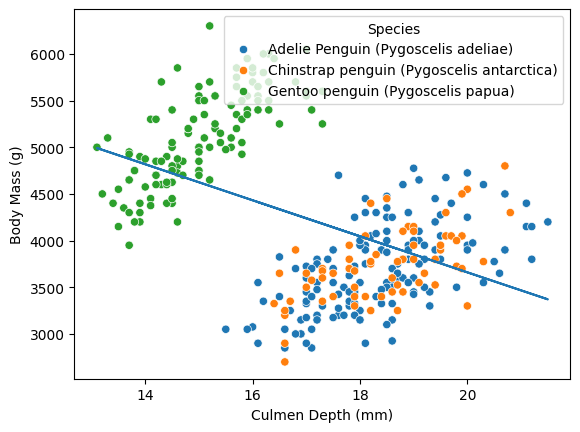

In [5]:
# same scatterplot but showing data per species
sns.scatterplot(x=x, y=y, hue=data["Species"])
plt.plot(x, mymodel)
plt.show()

We confirmed that the groups in the data correspond to species. It is also evident that the relationship within each group seems to be positive, and not negative, as the overall data suggests. We can plot the regression line for each group running the following code:

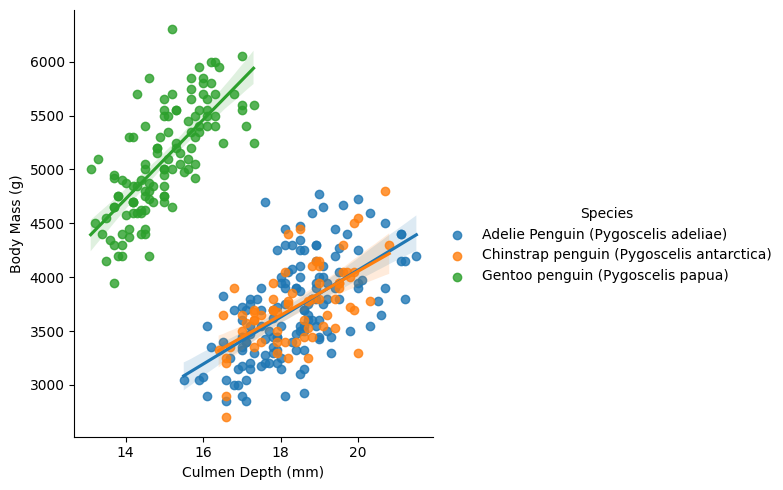

In [6]:
# Plot by group
sns.lmplot(x='Culmen Depth (mm)', y='Body Mass (g)', hue="Species", data=data)
plt.show()

Within each group, the relationship is clearly positive, despite an overall negative relationship. This paradox is called the `Simpson's Paradox` (nothing to do with the Simpson's series), as described by Simpson (1951).

It is therefore more appropriate to run the regression to each species separately.

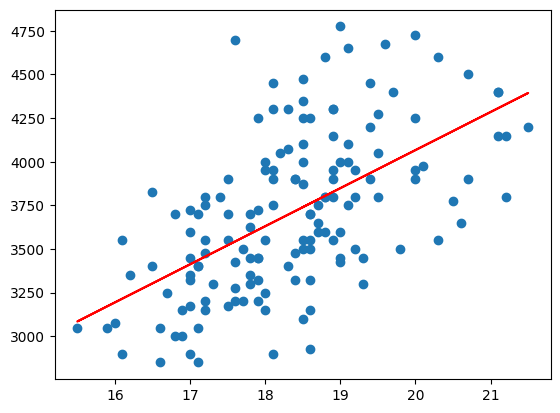

In [7]:
# Run same regression but only for the species 'versicolor'

x=data[(data['Species']=='Adelie Penguin (Pygoscelis adeliae)')]['Culmen Depth (mm)']
y=data[(data['Species']=='Adelie Penguin (Pygoscelis adeliae)')]['Body Mass (g)']

# Execute a method that returns some important key values of Linear Regression:
slope, intercept, r, p, std_err = stats.linregress(x, y)

# plot data with fitted line
def myfunc(x):
  return intercept + slope * x # function that returns fitted values

mymodel = list(map(myfunc, x)) # apply function to each x value

plt.scatter(x, y)
plt.plot(x, mymodel, color="red")
plt.show()

In [ ]:
# Model output table
x = sm.add_constant(x) # adding a constant (Intercept)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)

print_model = model.summary()
print(print_model)

### 2. Run multiple linear regression

When running multiple linear regression, the model will contain more than one predictor variable. The single effect of a variable may change in the presence of other variables. In the following example we will use the `Penguin` dataset to regress the body mass as a function of the remaining variables.

In [8]:
y=data['Body Mass (g)'] # dependent variable
x=data[["Culmen Depth (mm)", "Culmen Length (mm)", "Flipper Length (mm)"]] # independent variables

x = sm.add_constant(x) # adding a constant (Intercept)

model = sm.OLS(y, x).fit() # fit the model
predictions = model.predict(x) # make the predictions by the model

print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:          Body Mass (g)   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          9.26e-103
Time:                        11:41:47   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -6445.4760    

### Explanation of Multiple Linear Regression Model Output Terms:

The output table from `statsmodels` provides a comprehensive summary of the regression analysis. Here's a breakdown of the key terms:

**Model Statistics (Top Section):**

*   **Dep. Variable (Dependent Variable):** This is the variable your model is trying to predict or explain, in this case, 'Body Mass (g)'.
*   **R-squared:** This indicates the proportion of the variance in the dependent variable that can be explained by your independent variables (predictors). A value of 0.764 means 76.4% of the variation in 'Body Mass (g)' can be explained by 'Culmen Depth (mm)', 'Culmen Length (mm)', and 'Flipper Length (mm)'. It ranges from 0 to 1, with higher values indicating a better fit.
*   **Adj. R-squared (Adjusted R-squared):** This is a modified R-squared that accounts for the number of predictors in the model. It only increases if the new predictor improves the model more than would be expected by chance, making it useful for comparing models with different numbers of predictors. It helps prevent overfitting.
*   **F-statistic:** This tests the overall significance of the regression model. It evaluates the null hypothesis that all the regression coefficients (except the intercept) are equal to zero. A large F-statistic suggests that at least one of your independent variables is significantly related to the dependent variable.
*   **Prob (F-statistic):** This is the p-value associated with the F-statistic. A very small p-value (e.g., 9.26e-103, which is practically zero) indicates that the overall model is statistically significant, meaning the predictors together explain a significant amount of the variation in the dependent variable.
*   **Log-Likelihood:** A measure of how well the model fits the data. Higher values generally indicate a better fit.
*   **AIC (Akaike Information Criterion):** Used for model selection, balancing model fit with complexity. Lower AIC values are preferred.
*   **BIC (Bayesian Information Criterion):** Similar to AIC, but penalizes model complexity more heavily, especially for larger datasets. Lower BIC values are preferred.
*   **No. Observations:** The number of data points used in the analysis.
*   **Df Residuals (Degrees of Freedom Residuals):** The number of observations minus the number of parameters estimated in the model (including the intercept).
*   **Df Model (Degrees of Freedom Model):** The number of independent variables in the model.

**Coefficients Section (Middle Section):**

*   **coef (Coefficient):** The estimated value for each predictor. For 'const' (intercept), it's the expected value of 'Body Mass (g)' when all predictors are zero. For 'Culmen Depth (mm)', for example, it's the estimated change in 'Body Mass (g)' for a one-unit increase in 'Culmen Depth (mm)', holding other predictors constant.
*   **std err (Standard Error):** The standard deviation of the coefficient estimate. A smaller standard error indicates a more precise estimate.
*   **t (t-statistic):** Used to test the null hypothesis that the coefficient is zero. It's the ratio of the coefficient to its standard error.
*   **P>|t| (p-value):** The probability of observing a t-statistic as extreme as, or more extreme than, the calculated one, assuming the null hypothesis (coefficient is zero) is true. A small p-value (typically < 0.05) suggests that the predictor is statistically significant.
    *   For 'Culmen Depth (mm)' (p=0.198) and 'Culmen Length (mm)' (p=0.540), the p-values are high, suggesting they might not be individually significant predictors of 'Body Mass (g)' in this model, given the presence of 'Flipper Length (mm)'.
    *   'Flipper Length (mm)' (p=0.000) is highly significant.
*   **[0.025 0.975] (95% Confidence Interval):** This range provides an estimate of the true population coefficient with 95% confidence. If this interval includes zero, it suggests the coefficient is not statistically significant.

**Assumptions Diagnostics (Bottom Section):**

*   **Omnibus:** A test of the normality of the residuals. A significant p-value (Prob(Omnibus) < 0.05) suggests that the residuals are not normally distributed. Here, `0.061` suggests it's borderline, but not strongly rejecting normality.
*   **Prob(Omnibus):** The p-value for the Omnibus test.
*   **Jarque-Bera (JB):** Another test for normality of residuals, based on skewness and kurtosis. A significant p-value (Prob(JB) < 0.05) indicates non-normal residuals. Here, `0.0649` is borderline.
*   **Skew:** A measure of the asymmetry of the residuals' distribution. A value near 0 indicates symmetry.
*   **Kurtosis:** A measure of the 'tailedness' of the residuals' distribution. For a normal distribution, kurtosis is 3 (or 0 if excess kurtosis is reported).
*   **Durbin-Watson:** Tests for autocorrelation (correlation between consecutive residuals). A value near 2 indicates no autocorrelation. Here, `1.968` is close to 2, suggesting no significant autocorrelation.
*   **Cond. No. (Condition Number):** A measure of multicollinearity (correlation among independent variables). A high condition number (like 5.44e+03) indicates strong multicollinearity, which means some of your independent variables are highly correlated with each other. This can make coefficient estimates unstable and difficult to interpret individually, as noted in the 'Notes' section below the table.

We may also use the formula interface of statsmodels (like in R) to compute regression with multiple predictors. We just need append the predictors to the formula via a '+' symbol.

In [9]:
# import formula api as alias smf
import statsmodels.formula.api as smf

# In order to apply a formula, the header names cannot have spaces - need to change the header names
data.rename(columns={'Body Mass (g)':'body_mass'}, inplace=True) # inplace="True" means that df will be updated
data.rename(columns={'Culmen Depth (mm)':'culmen_depth'}, inplace=True)
data.rename(columns={'Culmen Length (mm)':'culmen_length'}, inplace=True)
data.rename(columns={'Flipper Length (mm)':'flipper_length'}, inplace=True)

# formula: response ~ predictor1 + predictor2 + ...
model = smf.ols(formula='body_mass ~ culmen_depth + culmen_length + flipper_length', data=data).fit()
print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:              body_mass   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          9.26e-103
Time:                        11:52:17   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -6445.4760    566.130    -11.

We will now plot the partial response (or dependence) plots, which represents the effect of each variable in the presence of the remaining. This effect may be very different from the single effect, i.e., when running simple linear regression with each predictor.

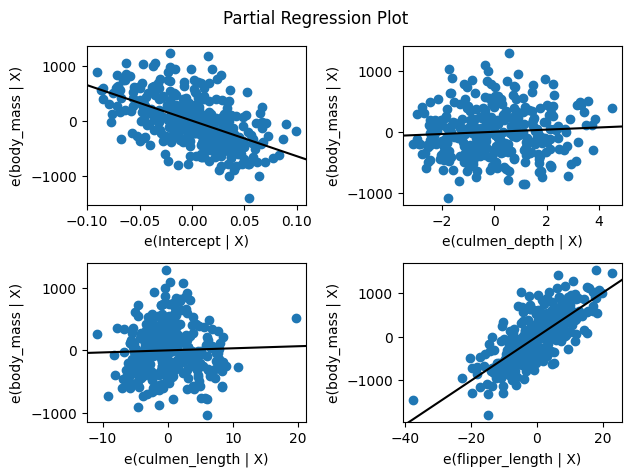

In [10]:
fig = sm.graphics.plot_partregress_grid(model)
fig.tight_layout(pad=1.0)

The chart below shows how the single effect of 'culmen depth' is very different from its joint effect with the remaining variables.

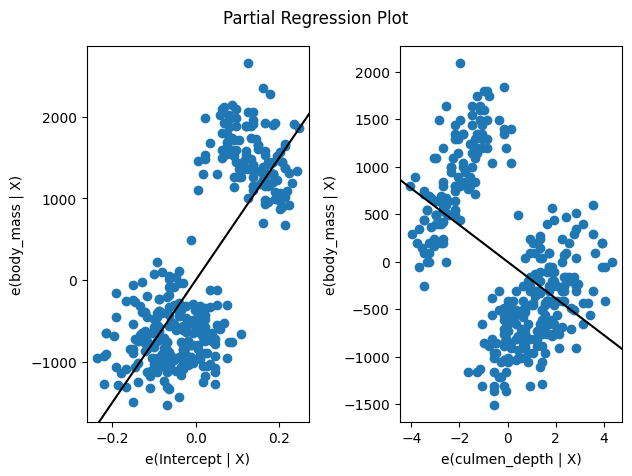

In [11]:
# formula: response ~ predictor
model2 = smf.ols(formula='body_mass ~ culmen_depth', data=data).fit()
fig = sm.graphics.plot_partregress_grid(model2)
fig.tight_layout(pad=1.0)

The next chart uses the plot_fit function to plot the fitted values versus a chosen independent variable. It includes prediction confidence intervals and optionally plots the true dependent variable. Let's check the fit plot for each predictor.


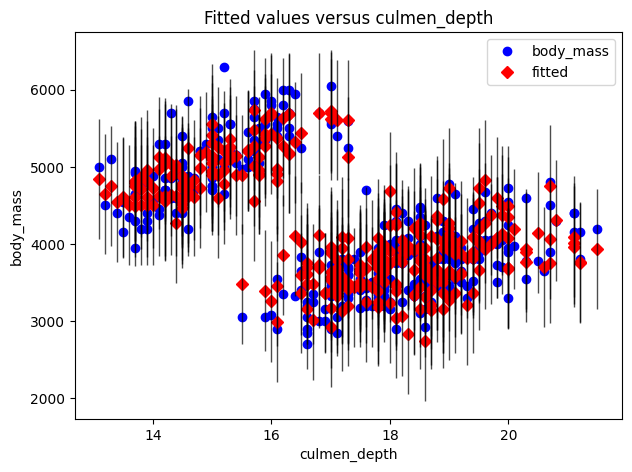

In [12]:
fig = sm.graphics.plot_fit(model, "culmen_depth") # plot the regression line for the variable "culmen_depth"
fig.tight_layout(pad=1.0) # adjust the padding between and around subplots.

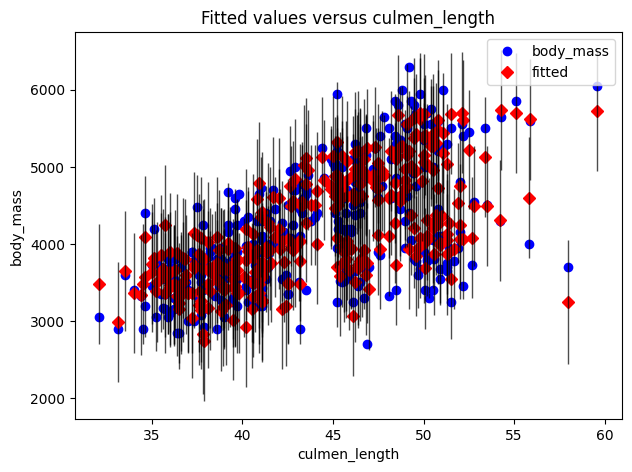

In [13]:
fig = sm.graphics.plot_fit(model, "culmen_length")
fig.tight_layout(pad=1.0)

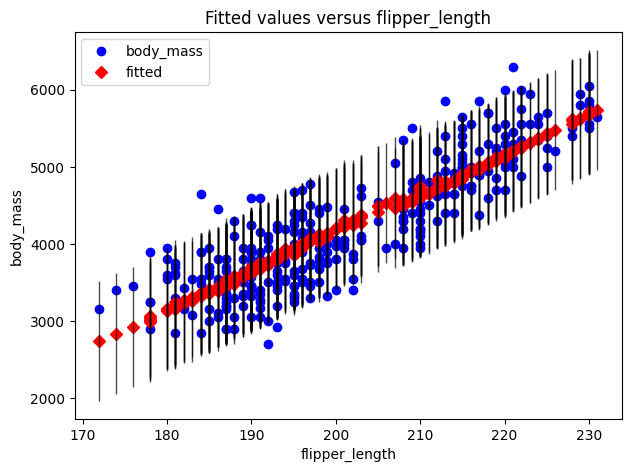

In [14]:
fig = sm.graphics.plot_fit(model, "flipper_length")
fig.tight_layout(pad=1.0)

An important step when running regression is to perform a regression diagnostic to check that the assumptions are met.

The *statsmodel* has no specific function to run the most common diagnostic plots, but it provides a code to generate such function. Check below.

In [15]:
# Code to produce functions to run diagnostic plots
# https://www.statsmodels.org/dev/examples/notebooks/generated/linear_regression_diagnostics_plots.html

# base code
import numpy as np
import seaborn as sns
from statsmodels.tools.tools import maybe_unwrap_results
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from typing import Type
import statsmodels

style_talk = 'seaborn-talk'    #refer to plt.style.available

class Linear_Reg_Diagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Author:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.
    """


    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)


    def __call__(self, plot_context='seaborn-paper'):
        # print(plt.style.available)
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(ax=ax[1,1])
            plt.show()

        self.vif_table()
        return fig, ax



    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.sort(residual_abs))
        abs_resid_top_3 = abs_resid[:3]
        for i, _ in enumerate(abs_resid_top_3):
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax


    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for r, i in enumerate(abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(np.flip(QQ.theoretical_quantiles, 0)[r], self.residual_norm[i]),
                ha='right', color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')
        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        xtemp, ytemp = self.__cooks_dist_line(0.5) # 0.5 line
        ax.plot(xtemp, ytemp, label="Cook's distance", lw=1, ls='--', color='red')
        xtemp, ytemp = self.__cooks_dist_line(1) # 1 line
        ax.plot(xtemp, ytemp, lw=1, ls='--', color='red')

        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        ax.legend(loc='upper right')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        print(vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y

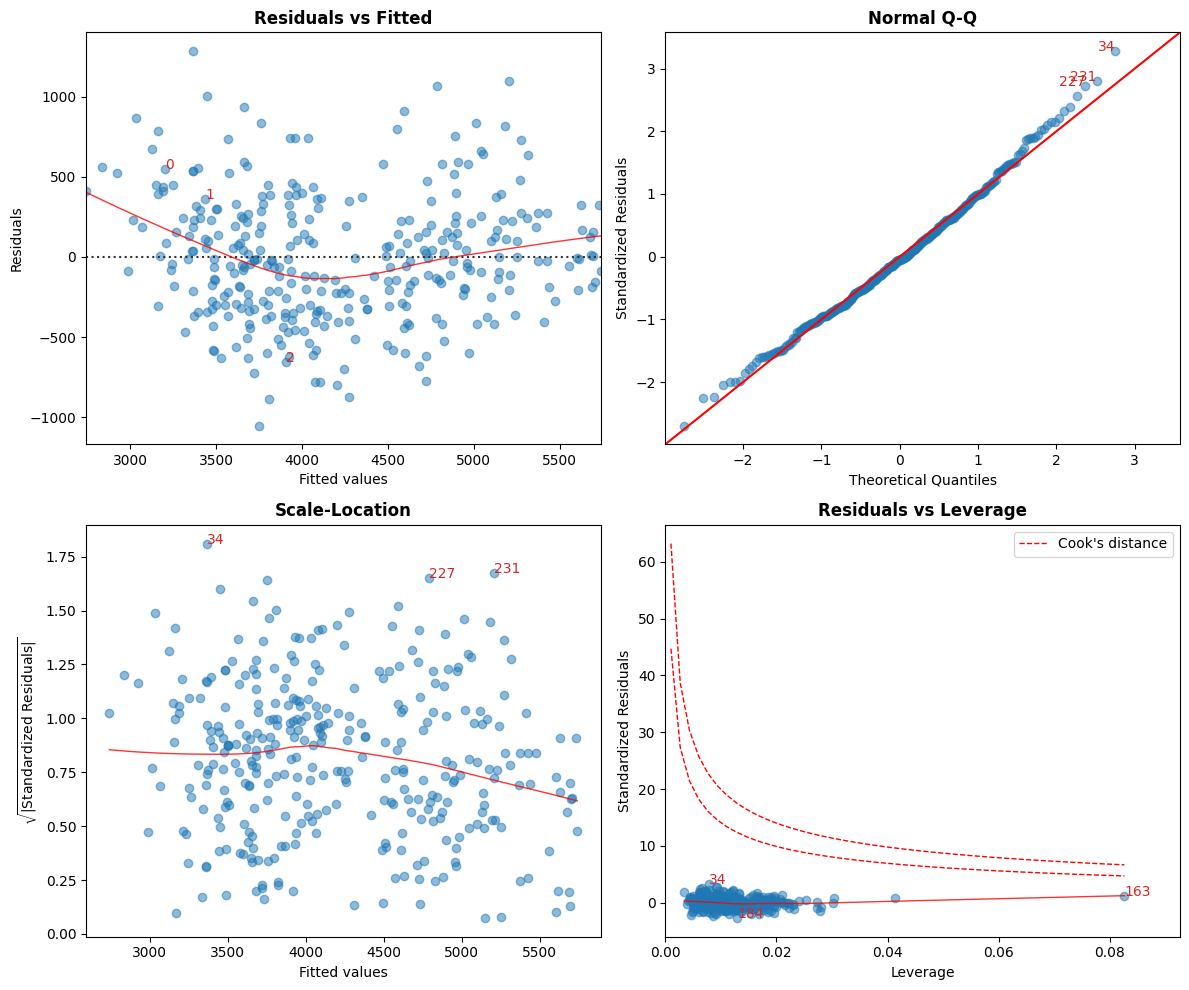

In [16]:
# Run diagnostic plots
cls = Linear_Reg_Diagnostic(model)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cls.residual_plot(ax=axes[0, 0])
cls.qq_plot(ax=axes[0, 1])
cls.scale_location_plot(ax=axes[1, 0])
cls.leverage_plot(ax=axes[1, 1])

plt.tight_layout()
plt.show()

### Explanation of Diagnostic Plots

These plots are used to check the assumptions of a linear regression model. Violations of these assumptions can lead to unreliable model results.

#### 1. Residuals vs Fitted Plot

*   **Purpose:** This plot helps detect non-linearity, unequal error variances (heteroscedasticity), and outliers.
*   **Interpretation:**
    *   **Good Fit:** If the residuals are randomly scattered around the horizontal line at zero, with no clear pattern, it suggests that the linear model is appropriate, and the variance of residuals is constant.
    *   **Problems:** If you see a curved pattern, it suggests non-linearity, meaning a linear model might not be the best fit. A funnel or cone shape (residuals widening or narrowing as fitted values increase) indicates heteroscedasticity (non-constant variance).
*   **Your Plot:** In your plot, the red line (LOWESS smooth) is relatively flat and close to zero, which is good. The points are somewhat scattered, though there's a slight increase in spread towards higher fitted values, which might suggest a minor degree of heteroscedasticity, but it's not severe.

#### 2. Normal Q-Q Plot

*   **Purpose:** This plot is used to check if the residuals are normally distributed.
*   **Interpretation:**
    *   **Good Fit:** If the points closely follow the 45-degree diagonal line, it suggests that the residuals are approximately normally distributed.
    *   **Problems:** Deviations from the line, especially at the tails, indicate departures from normality. For instance, a curved pattern suggests skewness or heavier/lighter tails than a normal distribution.
*   **Your Plot:** The points mostly follow the diagonal line, especially in the middle. There's a slight deviation at the extremes, suggesting some minor departure from perfect normality, but it's generally acceptable for many practical purposes.

#### 3. Scale-Location Plot (or Spread-Location Plot)

*   **Purpose:** This plot is another way to check the assumption of homoscedasticity (constant variance of residuals).
*   **Interpretation:**
    *   **Good Fit:** A horizontal line (the red LOWESS line) with randomly spread points indicates constant variance across the range of fitted values.
    *   **Problems:** An upward or downward sloping line, or a widening/narrowing spread of points, indicates heteroscedasticity.
*   **Your Plot:** Similar to the Residuals vs Fitted plot, the red line is mostly flat, suggesting reasonable homoscedasticity. The spread of points doesn't show a strong pattern of increasing or decreasing variance, reinforcing that heteroscedasticity is not a major issue here.

#### 4. Residuals vs Leverage Plot

*   **Purpose:** This plot helps identify influential observations, which are data points that have a strong impact on the regression line.
*   **Interpretation:**
    *   **Leverage:** Points with high leverage are those far away from the center of the independent variable data, potentially pulling the regression line towards them. These are on the right side of the plot.
    *   **Residuals:** Points with large standardized residuals are outliers in the dependent variable.
    *   **Cook's Distance:** The dashed red lines represent Cook's distance contours. Points falling outside these contours (especially above 0.5 or 1) are considered highly influential and might warrant further investigation or removal if they are errors.
*   **Your Plot:** Your plot shows a few points with higher leverage but they generally fall within or close to the Cook's distance lines (0.5 and 1). This suggests that while there might be some points influencing the model more than others, there aren't many extremely influential points that would drastically alter the model if removed.

## References

Linear regression diagnostics https://www.statsmodels.org/dev/examples/notebooks/generated/linear_regression_diagnostics_plots.html

Ordinary Least Squares https://www.statsmodels.org/dev/examples/notebooks/generated/ols.html

Regression Plots https://www.statsmodels.org/dev/examples/notebooks/generated/regression_plots.html

 Simpson, Edward H. (1951). The Interpretation of Interaction in Contingency Tables. *Journal of the Royal Statistical Society*, Series B. 13: 238–241.